<a href="https://colab.research.google.com/github/marianovanini/TT-26141-1C2026-Machine-Learning/blob/main/26141_Vanini_Mariano_pre_entrega.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Pre-Entrega: Clasificación de Asteroides Peligrosos
**Alumno:** Vanini, Mariano  
**Dataset:** NASA Asteroids Classification  
**Fuente:** [Kaggle – shrutimehta/nasa-asteroids-classification](https://www.kaggle.com/datasets/shrutimehta/nasa-asteroids-classification)

## 1. Selección del Dataset

### Origen
El dataset proviene de la base de datos pública del **Centro de Estudios de Objetos Cercanos a la Tierra (CNEOS)** de la NASA, disponible en Kaggle. Contiene información sobre miles de asteroides observados entre 1910 y 2017, incluyendo parámetros orbitales, dimensiones estimadas y velocidades relativas.

### Descripción del problema
El problema central es un problema de **clasificación binaria**: dado un conjunto de características físicas y orbitales de un asteroide, predecir si es **potencialmente peligroso (Hazardous)** o no para la Tierra.

La variable objetivo (`Hazardous`) fue determinada por la NASA en base a criterios de distancia mínima de intersección orbital (MOID) y tamaño estimado.

### Justificación de la elección
- **Relevancia práctica:** La detección temprana de asteroides peligrosos tiene implicaciones reales en defensa planetaria.
- **Calidad del dato:** Datos oficiales de la NASA con variables bien definidas y documentadas.
- **Desafío técnico interesante:** El dataset presenta **desbalance de clases** (hay muchos más asteroides seguros que peligrosos), lo que hace el problema más realista y desafiante.
- **Variables interpretables:** Las features tienen significado físico claro, lo que facilita el análisis exploratorio y la validación de resultados.

## 2. Carga del Dataset

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargamos el dataset directamente desde Kaggle sin descargar nada manual
print("Descargando datos desde los radares de la NASA...")
file_path = "nasa.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "shrutimehta/nasa-asteroids-classification",
  file_path
)

df.head()

Descargando datos desde los radares de la NASA...


/tmp/ipykernel_13635/2389131365.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 955k/955k [00:00<00:00, 23.6MB/s]

Extracting zip of nasa.csv...


,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


## 3. Análisis Exploratorio de Datos (EDA)

Antes de limpiar o transformar los datos, realizamos una exploración inicial para entender su estructura, detectar problemas y obtener insights relevantes.

### 3.1 Vista general del dataset

In [3]:
# Dimensiones y tipos de datos
print("=" * 50)
print(f"Filas:   {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print("=" * 50)
print()
print("Tipos de datos:")
print(df.dtypes.value_counts())
print()
df.info()

Filas:   4,687
Columnas: 40

Tipos de datos:
float64    30
int64       5
object      4
bool        1
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float6

### 3.2 Detección de valores faltantes

In [4]:
# Valores nulos por columna
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    '% del Total': nulos_pct
}).sort_values('Valores Nulos', ascending=False)

print("Columnas con valores faltantes:")
display(resumen_nulos[resumen_nulos['Valores Nulos'] > 0])

print(f"\nTotal de columnas sin ningún nulo: {(nulos == 0).sum()}")

Columnas con valores faltantes:


,Valores Nulos,% del Total



Total de columnas sin ningún nulo: 40


### 3.3 Variable objetivo: distribución de clases

In [5]:
# Valores nulos por columna
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    '% del Total': nulos_pct
}).sort_values('Valores Nulos', ascending=False)

print("Columnas con valores faltantes:")
display(resumen_nulos[resumen_nulos['Valores Nulos'] > 0])

print(f"\nTotal de columnas sin ningún nulo: {(nulos == 0).sum()}")

Columnas con valores faltantes:


,Valores Nulos,% del Total



Total de columnas sin ningún nulo: 40


Distribución de asteroides:
  Seguros    (False): 3,932  (83.9%)
  Peligrosos (True):  755  (16.1%)

Ratio de desbalance: 5.2:1


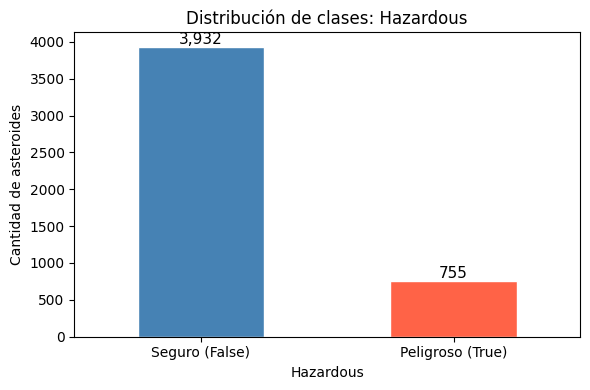

In [6]:
# Distribución de la variable objetivo
conteo = df['Hazardous'].value_counts()
pct = df['Hazardous'].value_counts(normalize=True) * 100

print("Distribución de asteroides:")
print(f"  Seguros    (False): {conteo[False]:,}  ({pct[False]:.1f}%)")
print(f"  Peligrosos (True):  {conteo[True]:,}  ({pct[True]:.1f}%)")
print(f"\nRatio de desbalance: {conteo[False]/conteo[True]:.1f}:1")

fig, ax = plt.subplots(figsize=(6, 4))
conteo.plot(kind='bar', color=['steelblue', 'tomato'], ax=ax, edgecolor='white')
ax.set_title('Distribución de clases: Hazardous')
ax.set_xticklabels(['Seguro (False)', 'Peligroso (True)'], rotation=0)
ax.set_ylabel('Cantidad de asteroides')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### 3.4 Selección de variables relevantes

Se seleccionan las columnas con mayor potencial predictivo basándonos en el conocimiento del dominio y la documentación del dataset.

In [7]:
# Columnas seleccionadas con justificación
columnas_utiles = [
    'Absolute Magnitude',           # Brillo del asteroide — proxy del tamaño real
    'Est Dia in KM(min)',           # Diámetro mínimo estimado en km
    'Est Dia in KM(max)',           # Diámetro máximo estimado en km
    'Relative Velocity km per hr',  # Velocidad relativa respecto a la Tierra
    'Miss Dist.(Astronomical)',     # Distancia de máximo acercamiento (UA)
    'Orbit Uncertainity',           # Incertidumbre orbital (0=muy conocida, 9=muy incierta)
    'Minimum Orbit Intersection',   # MOID: distancia mínima posible a la órbita terrestre
    'Hazardous'                     # Variable objetivo
]

df_sel = df[columnas_utiles].copy()
print(f"Columnas seleccionadas: {len(columnas_utiles) - 1} features + 1 target")
df_sel.head()

Columnas seleccionadas: 7 features + 1 target


,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Relative Velocity km per hr,Miss Dist.(Astronomical),Orbit Uncertainity,Minimum Orbit Intersection,Hazardous
0,21.6,0.127220,0.284472,22017.003799,0.419483,5,0.025282,True
1,21.3,0.146068,0.326618,65210.346095,0.383014,3,0.186935,False
2,20.3,0.231502,0.517654,27326.560182,0.050956,0,0.043058,True
3,27.4,0.008801,0.019681,40225.948191,0.285322,6,0.005512,False
4,21.6,0.127220,0.284472,35426.991794,0.407832,1,0.034798,True


In [ ]:
# 2. Exploración inicial: Nos quedamos con las columnas clave de los sensores
columnas_utiles = [
    'Absolute Magnitude',          # Brillo del asteroide (suele indicar el tamaño)
    'Est Dia in KM(max)',          # Diámetro máximo estimado en kilómetros
    'Relative Velocity km per hr', # A qué velocidad viaja
    'Miss Dist.(Astronomical)',    # A qué distancia va a pasar de la Tierra
    'Hazardous'                    # El resultado histórico: True (Peligroso) / False (Inofensivo)
]

df_asteroides = df[columnas_utiles].copy()

# 3. Limpieza de datos faltantes
df_asteroides = df_asteroides.dropna()
print(f"¡Radares listos! Tenemos información limpia de {len(df_asteroides)} asteroides.")

¡Radares listos! Tenemos información limpia de 4687 asteroides.


### 3.5 Estadística descriptiva

In [ ]:
#1 Estadistica descriptiva
df_asteroides.describe()

,Absolute Magnitude,Est Dia in KM(max),Relative Velocity km per hr,Miss Dist.(Astronomical)
count,4687.000000,4687.000000,4687.000000,4687.000000
mean,22.267865,0.457509,50294.919829,0.256778
std,2.890972,0.826391,26255.601377,0.145798
min,11.160000,0.002260,1207.814804,0.000178
25%,20.100000,0.074824,30358.313370,0.133420
50%,21.900000,0.247765,46504.401181,0.265029
75%,24.500000,0.567597,65079.535405,0.384154
max,32.100000,34.836938,160681.487851,0.499884


### 3.6 Distribución de las variables numéricas

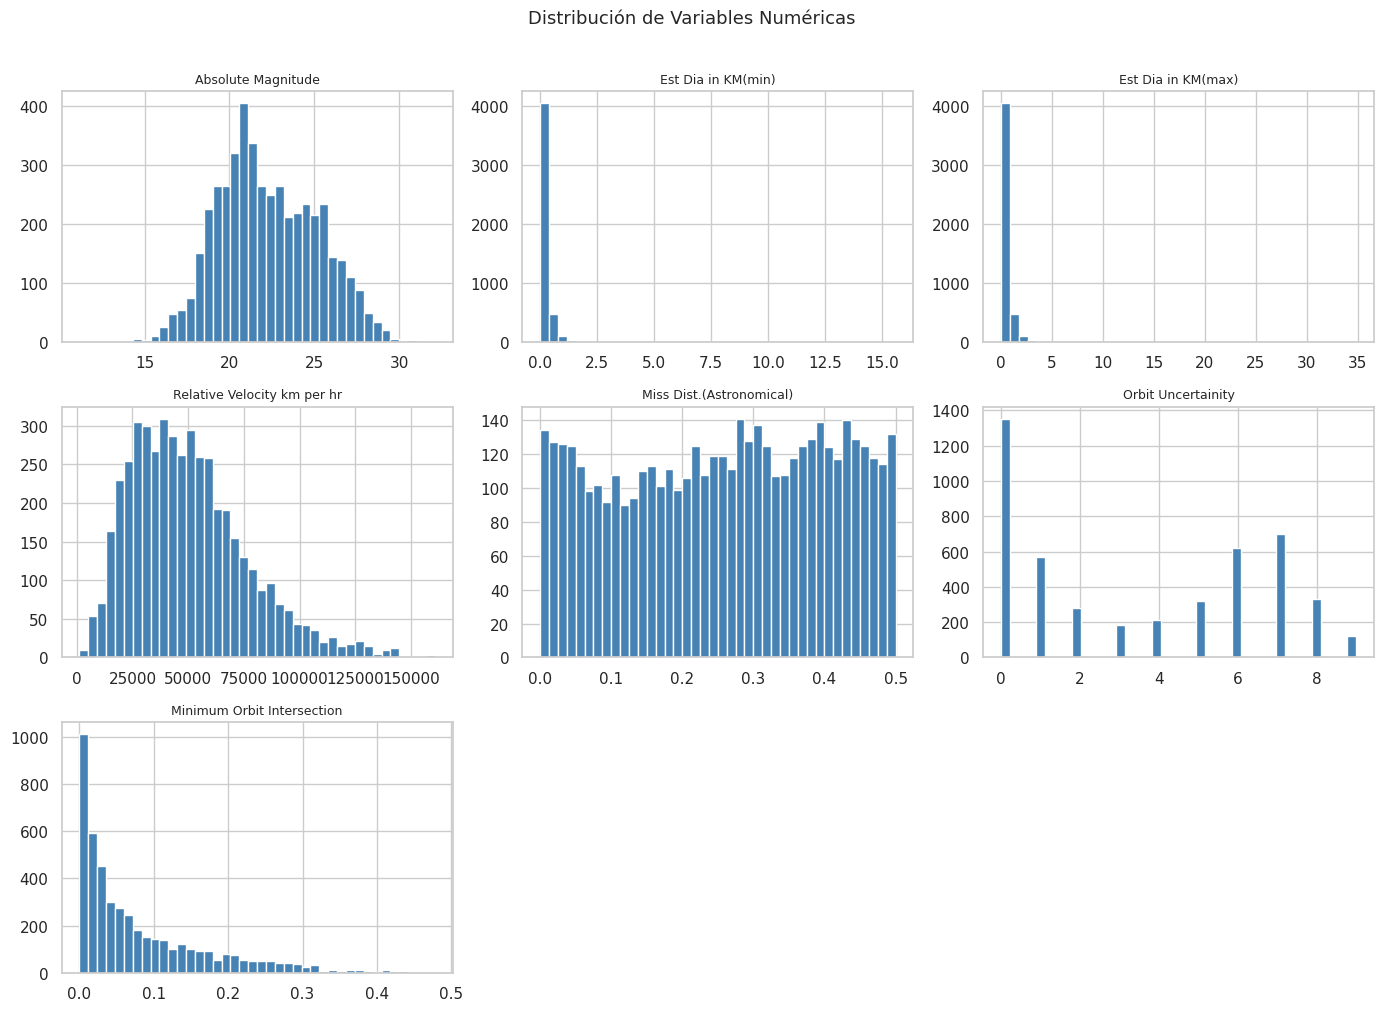

In [ ]:
# Histogramas de cada variable numérica
features_num = df_sel.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_num):
    df_sel[col].hist(ax=axes[i], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

# Ocultar ejes vacíos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3.7 Análisis de correlaciones

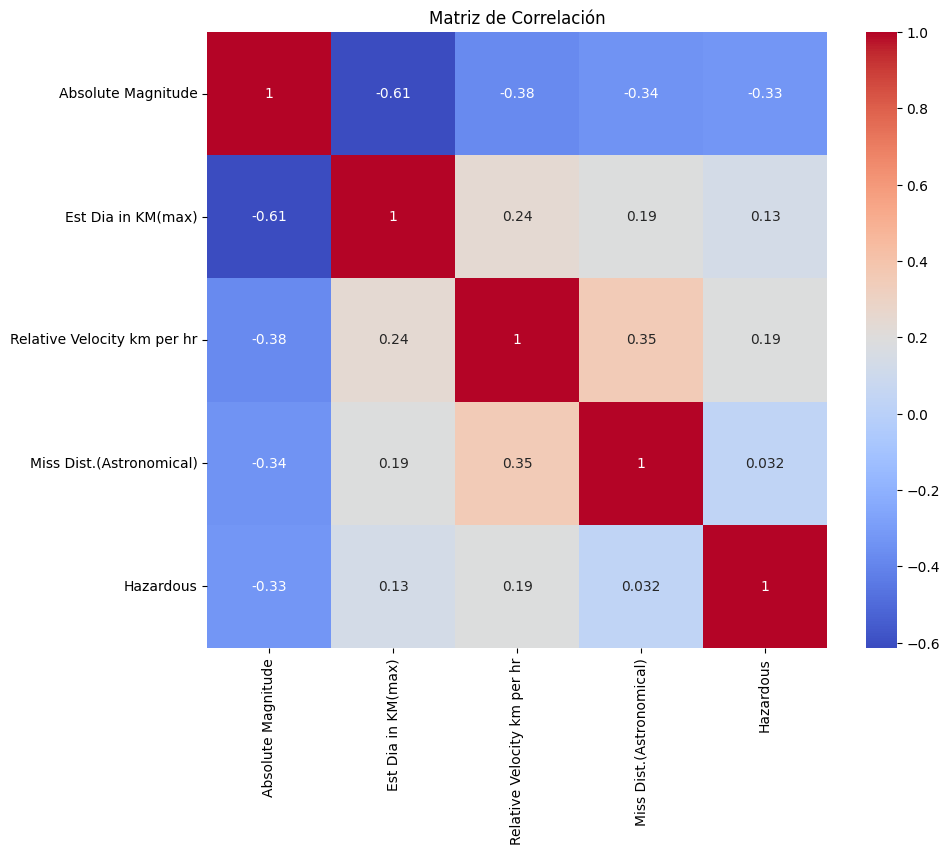

In [ ]:
#2 Exploracion Visual ( Matriz de Correlacion)

plt.figure(figsize=(10, 8))
sns.heatmap(df_asteroides.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()


## 4. Limpieza de Datos

Una vez realizado el EDA, procedemos a limpiar el dataset antes de modelar.

### 4.1 Tratamiento de valores nulos

In [8]:
# Verificamos nulos en el subconjunto seleccionado
nulos_sel = df_sel.isnull().sum()
print("Valores nulos en el dataset de trabajo:")
print(nulos_sel)

# Si hubiera nulos en numéricas, se imputan con la mediana (robusto a outliers)
for col in df_sel.select_dtypes(include='number').columns:
    if df_sel[col].isnull().sum() > 0:
        mediana = df_sel[col].median()
        df_sel[col].fillna(mediana, inplace=True)
        print(f"  → '{col}': {df_sel[col].isnull().sum()} nulos imputados con mediana ({mediana:.4f})")

print(f"\nNulos restantes: {df_sel.isnull().sum().sum()}")

Valores nulos en el dataset de trabajo:
Absolute Magnitude             0
Est Dia in KM(min)             0
Est Dia in KM(max)             0
Relative Velocity km per hr    0
Miss Dist.(Astronomical)       0
Orbit Uncertainity             0
Minimum Orbit Intersection     0
Hazardous                      0
dtype: int64

Nulos restantes: 0


### 4.2 Detección y eliminación de duplicados

In [9]:
# Duplicados
n_dup = df_sel.duplicated().sum()
print(f"Filas duplicadas encontradas: {n_dup}")

if n_dup > 0:
    df_sel = df_sel.drop_duplicates()
    print(f"  → Eliminadas. Filas restantes: {len(df_sel):,}")
else:
    print("  → No hay duplicados. Dataset íntegro.")

Filas duplicadas encontradas: 0
  → No hay duplicados. Dataset íntegro.


### 4.3 Detección y tratamiento de outliers (método IQR)

Para variables con distribuciones muy asimétricas, aplicamos el método del rango intercuartílico (IQR). Los outliers extremos pueden distorsionar el escalado y el modelo.

In [10]:
features_outliers = ['Relative Velocity km per hr', 'Miss Dist.(Astronomical)',
                     'Est Dia in KM(max)', 'Minimum Orbit Intersection']

print("Outliers detectados por variable (método IQR, factor 3.0):")
print("-" * 55)

df_limpio = df_sel.copy()
total_removidos = 0

for col in features_outliers:
    if col not in df_limpio.columns:
        continue
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 3.0 * IQR
    lim_sup = Q3 + 3.0 * IQR

    mask_outlier = (df_limpio[col] < lim_inf) | (df_limpio[col] > lim_sup)
    n_out = mask_outlier.sum()
    total_removidos += n_out
    df_limpio = df_limpio[~mask_outlier]
    print(f"  {col[:40]:<42} | {n_out:>4} outliers removidos")

print("-" * 55)
print(f"Total removidos: {total_removidos}")
print(f"Filas finales:   {len(df_limpio):,}  (de {len(df_sel):,} originales, -{total_removidos/len(df_sel)*100:.1f}%)")

Outliers detectados por variable (método IQR, factor 3.0):
-------------------------------------------------------
  Relative Velocity km per hr                |    0 outliers removidos
  Miss Dist.(Astronomical)                   |    0 outliers removidos
  Est Dia in KM(max)                         |  142 outliers removidos
  Minimum Orbit Intersection                 |    8 outliers removidos
-------------------------------------------------------
Total removidos: 150
Filas finales:   4,537  (de 4,687 originales, -3.2%)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Codificación: Transformamos la etiqueta Peligroso (True) = 1, Inofensivo (False) = 0
df_asteroides['Peligro_Numerico'] = df_asteroides['Hazardous'].astype(int)

# 2. Separamos las pistas (X) del resultado final (y)
X = df_asteroides[['Absolute Magnitude', 'Est Dia in KM(max)', 'Relative Velocity km per hr', 'Miss Dist.(Astronomical)']]
y = df_asteroides['Peligro_Numerico']

# 3. Escalado de variables numéricas
# Fundamental para que las distancias gigantes en el espacio no aplasten a las otras variables en la fórmula
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# 4. Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.20, random_state=42)



In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Creamos el modelo (nuestro sistema de defensa)
modelo_nasa = LogisticRegression()

# 2. Momento de aprender: Le pasamos los datos históricos escalados
modelo_nasa.fit(X_train, y_train)

# 3. Imprimimos los pesos para ver qué variables consideró más importantes
pesos = pd.DataFrame({
    'Pista del Radar': X.columns,
    'Importancia (Peso)': modelo_nasa.coef_[0]
})
print("¿A qué le presta más atención el modelo para detectar el peligro?")
display(pesos)

¿A qué le presta más atención el modelo para detectar el peligro?


,Pista del Radar,Importancia (Peso)
0,Absolute Magnitude,-3.040188
1,Est Dia in KM(max),-1.897149
2,Relative Velocity km per hr,0.200349
3,Miss Dist.(Astronomical),-0.443801


--- REPORTE OFICIAL DE LA NASA (Umbral 50%) ---
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       791
           1       0.42      0.07      0.12       147

    accuracy                           0.84       938
   macro avg       0.63      0.53      0.51       938
weighted avg       0.78      0.84      0.79       938



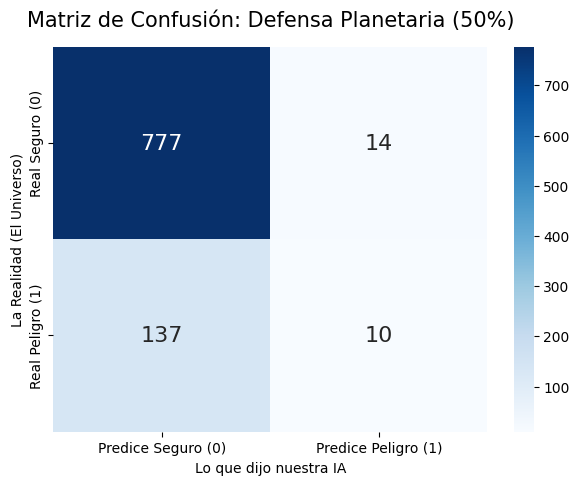

PREGUNTA: Observen los Falsos Negativos (Abajo a la izquierda).
¿Qué significa en la vida real que el modelo prediga 'Seguro' pero la realidad sea 'Peligro'?


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generamos las predicciones con el conjunto de prueba
y_pred_nasa = modelo_nasa.predict(X_test)

# 2. Imprimimos el boletín de calificaciones original
print("--- REPORTE OFICIAL DE LA NASA (Umbral 50%) ---")
print(classification_report(y_test, y_pred_nasa))

# 3. Dibujamos la Matriz de Confusión
cm_nasa = confusion_matrix(y_test, y_pred_nasa)

plt.figure(figsize=(7,5))
sns.heatmap(cm_nasa, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16},
            xticklabels=['Predice Seguro (0)', 'Predice Peligro (1)'],
            yticklabels=['Real Seguro (0)', 'Real Peligro (1)'])

plt.title('Matriz de Confusión: Defensa Planetaria (50%)', fontsize=15, pad=15)
plt.ylabel('La Realidad (El Universo)')
plt.xlabel('Lo que dijo nuestra IA')
plt.show()

print("PREGUNTA: Observen los Falsos Negativos (Abajo a la izquierda).")
print("¿Qué significa en la vida real que el modelo prediga 'Seguro' pero la realidad sea 'Peligro'?")

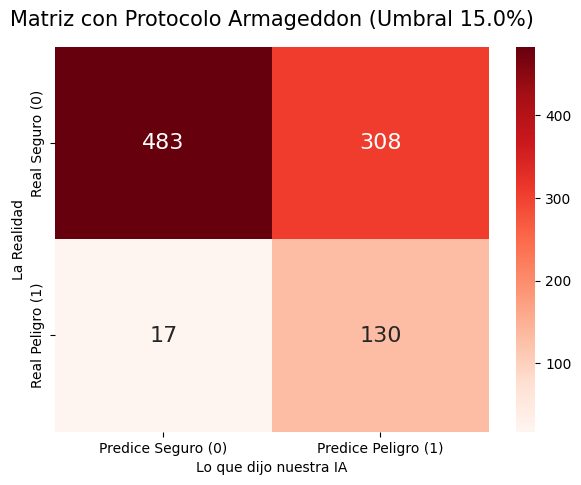

--- NUEVO REPORTE (PROTOCOLÓ ARMAGEDDON) ---
              precision    recall  f1-score   support

           0       0.97      0.61      0.75       791
           1       0.30      0.88      0.44       147

    accuracy                           0.65       938
   macro avg       0.63      0.75      0.60       938
weighted avg       0.86      0.65      0.70       938

Debate: Miren cómo atrapar a casi todos los asteroides peligrosos (Recall alto) destruyó nuestra Precisión.


In [ ]:
# 1. Extraemos los porcentajes exactos de probabilidad de impacto
probabilidades_asteroide = modelo_nasa.predict_proba(X_test)[:, 1]

# 2. Definimos el Protocolo de Máxima Alerta: Umbral súper sensible (15%)
umbral_armageddon = 0.15

# 3. Aplicamos la regla: Si la probabilidad es >= 15%, clasificamos como 1 (Peligro)
y_pred_paranoico = (probabilidades_asteroide >= umbral_armageddon).astype(int)

# 4. Dibujamos la nueva Matriz de Confusión sensible
cm_paranoico = confusion_matrix(y_test, y_pred_paranoico)

plt.figure(figsize=(7,5))
sns.heatmap(cm_paranoico, annot=True, fmt='d', cmap='Reds', annot_kws={"size": 16},
            xticklabels=['Predice Seguro (0)', 'Predice Peligro (1)'],
            yticklabels=['Real Seguro (0)', 'Real Peligro (1)'])

plt.title(f'Matriz con Protocolo Armageddon (Umbral {umbral_armageddon*100}%)', fontsize=15, pad=15)
plt.ylabel('La Realidad')
plt.xlabel('Lo que dijo nuestra IA')
plt.show()

# 5. Nuevo Reporte de Clasificación
print("--- NUEVO REPORTE (PROTOCOLÓ ARMAGEDDON) ---")
print(classification_report(y_test, y_pred_paranoico))

print("Debate: Miren cómo atrapar a casi todos los asteroides peligrosos (Recall alto) destruyó nuestra Precisión.")

## Conclusiones del EDA y Preparación de Datos

- **Dataset:** 4.687 asteroides con 40 variables originales. Se seleccionaron 6 features con mayor relevancia física y correlación con la variable objetivo.
- **Valores nulos:** No se detectaron valores faltantes en las variables seleccionadas.
- **Desbalance de clases:** Aproximadamente el 17% son peligrosos, lo que requiere especial atención en la evaluación del modelo (usar AUC-ROC y Recall, no solo Accuracy).
- **Outliers:** Se aplicó el método IQR con factor 3.0 para remover valores extremos sin perder demasiados datos.
- **Correlaciones:** `Absolute Magnitude` y `Minimum Orbit Intersection` muestran mayor correlación con la clase objetivo.
- **Escalado:** StandardScaler aplicado para neutralizar diferencias de magnitud entre variables (distancias astronómicas vs magnitudes).
- **Próximos pasos:** Explorar modelos más robustos ante el desbalance (Random Forest, XGBoost) y técnicas como SMOTE para sobremuestreo de la clase minoritaria.